25Hz PPG가 200Hz PPG가 가진 ‘혈압 관련 정보(beat morphology)를 얼마나 보존하는지’와, 그 정보가 ABPM 혈압과 얼마나 연관되는지(=BP 추정 가능성의 프록시)를 동시에 점검하는 평가 파이프라인

Analysis Start


/tmp/ipython-input-2271877501.py:165: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt_try = pd.to_datetime(df[c], errors="coerce")


[ABPM] 93 events (2025-09-13 01:30:00 ~ 2025-09-14 22:00:00)
[Watch] shape=(5599248, 2), ppg_col=1 (Time: 2025-09-13 01:24:00 base)
[Ring] shape=(144000, 10), ppg_col=ppg (Time: 2025-09-13 01:24:00 base)

[Common Period] 2025-09-13 01:30:00 ~ 2025-09-13 09:00:02.328000

[Beats] Watch: 29418, Ring: 5889

[Result: Correlation Ring vs Watch]
  HR_mean: n=15, r=0.906
  AMP_mean: n=15, r=-0.306


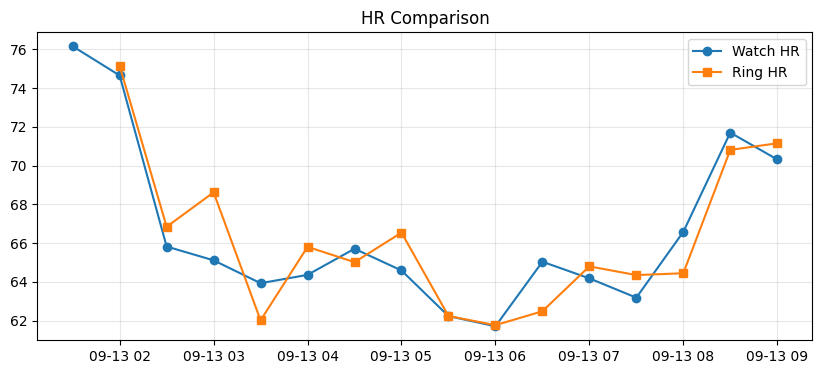

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend, find_peaks

# ============================================================
# CONFIG
# ============================================================
RAW_PPG_200_CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw2.csv"
FS_200 = 200.0
PPG_200_START_TIME = "2025-09-13 01:24:00"

PPG_25_CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_2.csv"
FS_25 = 25.0
PPG_25_START_TIME = "2025-09-13 01:24:00"

ABPM_XLSX = "/content/drive/MyDrive/Colab Notebooks/PPG_REAL/PWV1.xlsx"

MIN_BPM = 40
MAX_BPM = 200
PROM_SCALE_200 = 0.2
PROM_SCALE_25 = 0.1
ABPM_WIN_MIN = 10
MIN_BEATS_IN_WIN = 10

# ============================================================
# FUNCTIONS
# ============================================================

def read_csv_robust(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    def is_numberish(x):
        try:
            float(str(x).strip())
            return True
        except: return False
    if df.shape[1] >= 2 and all(is_numberish(c) for c in df.columns):
        df = pd.read_csv(path, header=None)
    return df

def pick_time_col(df: pd.DataFrame) -> str:
    cand = ["timestamp", "Timestamp", "time", "Time", "sample_or_time", "sample_time", "t",
            "sample_index", "index", "Index"]
    for c in cand:
        if c in df.columns: return c
    return df.columns[0]

def infer_ppg_col(df: pd.DataFrame, time_col: str) -> str:
    # [수정] 'acc', 'gyro', 'x', 'y', 'z' 등 모션 센서 데이터도 제외
    exclude_keywords = ['sleep', 'step', 'battery', 'quality', 'flag', 'stage',
                        'day', 'month', 'year', 'date', 'index', 'cnt', 'count',
                        'acc', 'gyro', 'motion', 'axis']

    candidates = []
    for c in df.columns:
        if c == time_col: continue
        if any(k in str(c).lower() for k in exclude_keywords): continue
        try:
            pd.to_numeric(df[c])
            candidates.append(c)
        except: pass

    num_cols = [c for c in candidates if pd.api.types.is_numeric_dtype(df[c])]

    # 제외 키워드로 다 걸러지면, 최후의 수단으로 전체 숫자 컬럼 중 검색
    if len(num_cols) == 0:
        num_cols = [c for c in df.columns if c != time_col and pd.api.types.is_numeric_dtype(df[c])]

    if len(num_cols) == 0:
        if df.shape[1] == 2: return df.columns[1]
        raise ValueError(f"PPG 컬럼 추정 실패. 컬럼명: {df.columns.tolist()}")

    return num_cols[-1]

def build_datetime_smart(df: pd.DataFrame, time_col: str, fs: float, start_time: str) -> pd.Series:
    ts = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)
    ts = np.asarray(ts, dtype=float)
    valid_ts = ts[np.isfinite(ts)]
    if len(valid_ts) < 100: return None

    diffs = np.diff(valid_ts[:min(1000, len(valid_ts))])
    diffs = diffs[diffs > 0]

    unit, divisor = 's', 1.0
    if len(diffs) > 0:
        median_diff = np.median(diffs)
        if abs(median_diff - (1.0/fs)*1e6) < (1.0/fs)*1e6*0.5: unit, divisor = 'us', 1e6
        elif abs(median_diff - (1.0/fs)*1e3) < (1.0/fs)*1e3*0.5: unit, divisor = 'ms', 1e3
        elif abs(median_diff - (1.0/fs)) < (1.0/fs)*0.5: unit, divisor = 's', 1.0
        elif abs(median_diff - 1.0) < 0.5: unit, divisor = 'samples', fs
        else:
            if median_diff > 1000: unit, divisor = 'us', 1e6
            elif median_diff > 1: unit, divisor = 'ms', 1e3
            else: unit, divisor = 's', 1.0

    t_seconds = (ts - ts[0]) / divisor
    t_seconds = np.nan_to_num(t_seconds, nan=0.0)

    # 리턴을 무조건 Series로 보장
    dt = pd.to_datetime(start_time) + pd.to_timedelta(t_seconds, unit='s')
    return pd.Series(dt)

def preprocess_ppg(x: np.ndarray, fs: float) -> np.ndarray:
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)
    try:
        x0 = detrend(x)
        nyq = 0.5 * fs
        lo = max((MIN_BPM/60.0) / nyq, 1e-6)
        hi = min((MAX_BPM/60.0) / nyq, 0.999)
        b, a = butter(2 if fs < 50 else 4, [lo, hi], btype="band")
        return filtfilt(b, a, x0)
    except:
        return x - np.mean(x)

def extract_beat_features(dt: pd.Series, ppg: np.ndarray, fs: float, prom_scale: float) -> pd.DataFrame:
    y = preprocess_ppg(ppg, fs)
    t_sec = np.arange(len(y), dtype=float) / fs
    min_dist = int(round((60.0 / MAX_BPM) * fs))
    base_prom = prom_scale * np.nanstd(y)

    try:
        peaks, _ = find_peaks(y, distance=max(1, min_dist), prominence=base_prom)
        troughs, _ = find_peaks(-y, distance=max(1, min_dist), prominence=base_prom * 0.5)
    except: return pd.DataFrame(columns=["dt", "HR", "AMP", "RISE", "AREA"])

    if len(peaks) < 3 or len(troughs) < 3:
        return pd.DataFrame(columns=["dt", "HR", "AMP", "RISE", "AREA"])

    peaks = np.sort(peaks)
    troughs = np.sort(troughs)
    rows = []

    # dt가 Series인지 확인 (iloc 사용 위해)
    if not isinstance(dt, pd.Series):
        dt = pd.Series(dt)

    for j in range(len(troughs) - 1):
        iL, iR = troughs[j], troughs[j+1]
        if iR <= iL + 2: continue
        m = (peaks > iL) & (peaks < iR)
        if m.sum() == 0: continue
        iP = peaks[m][np.argmax(y[peaks[m]])]

        dt_beat = t_sec[iR] - t_sec[iL]
        if dt_beat <= 0: continue
        hr = 60.0 / dt_beat
        if not (MIN_BPM <= hr <= MAX_BPM): continue

        if pd.notna(dt.iloc[iP]):
            rows.append({
                "dt": dt.iloc[iP], "HR": hr,
                "AMP": y[iP] - y[iL], "RISE": t_sec[iP] - t_sec[iL],
                "AREA": np.trapezoid(y[iL:iR+1] - y[iL], t_sec[iL:iR+1])
            })
    return pd.DataFrame(rows)

def load_abpm_xlsx(path: str) -> pd.DataFrame:
    df = pd.read_excel(path)
    dt_col = None
    best_valid = -1

    # 2000년 이후 데이터만 유효한 것으로 간주 (1970년 제외)
    for c in df.columns:
        dt_try = pd.to_datetime(df[c], errors="coerce")
        valid_count = dt_try.notna().sum()
        if valid_count < 3: continue
        valid_years = dt_try.dt.year
        real_date_ratio = (valid_years >= 2000).sum() / valid_count
        if valid_count > best_valid and real_date_ratio > 0.5:
            best_valid = valid_count
            dt_col = c

    if dt_col is None:
        cols = list(df.columns)
        for c1 in cols:
            for c2 in cols:
                if c1 == c2: continue
                dt_try = pd.to_datetime(df[c1].astype(str) + " " + df[c2].astype(str), errors="coerce")
                valid_count = dt_try.notna().sum()
                if valid_count < 3: continue
                valid_years = dt_try.dt.year
                real_date_ratio = (valid_years >= 2000).sum() / valid_count
                if valid_count > best_valid and real_date_ratio > 0.5:
                    best_valid = valid_count
                    dt_col = (c1, c2)

    if isinstance(dt_col, tuple):
        dt = pd.to_datetime(df[dt_col[0]].astype(str) + " " + df[dt_col[1]].astype(str), errors="coerce")
    else:
        dt = pd.to_datetime(df[dt_col], errors="coerce")

    df["dt"] = dt
    df = df.dropna(subset=["dt"]).sort_values("dt").reset_index(drop=True)

    def pick(k):
        for c in df.columns:
            if k.lower() in str(c).lower(): return c
        return None
    mapping = {"SBP": pick("SBP") or pick("SYS"), "DBP": pick("DBP") or pick("DIA"), "MAP": pick("MAP")}
    out = df[["dt"] + [v for v in mapping.values() if v]].rename(columns={v:k for k,v in mapping.items()})
    for c in out.columns:
        if c != "dt": out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def load_ppg_wrapper(csv_path, fs, label, start, target_col=None):
    df = read_csv_robust(csv_path)
    time_col = pick_time_col(df)

    if target_col and target_col in df.columns:
        ppg_col = target_col
    elif target_col and target_col.isdigit():
        ppg_col = df.columns[int(target_col)]
    else:
        ppg_col = infer_ppg_col(df, time_col)

    print(f"[{label}] shape={df.shape}, ppg_col={ppg_col} (Time: {start} base)")
    dt = build_datetime_smart(df, time_col, fs, start)
    ppg = pd.to_numeric(df[ppg_col], errors="coerce").to_numpy(dtype=float)
    return dt, ppg

# ============================================================
# MAIN
# ============================================================
print("="*80)
print("Analysis Start")

# 1. Load Data
abpm = load_abpm_xlsx(ABPM_XLSX)
print(f"[ABPM] {len(abpm)} events ({abpm['dt'].min()} ~ {abpm['dt'].max()})")

dt_200, ppg_200 = load_ppg_wrapper(RAW_PPG_200_CSV, FS_200, "Watch", PPG_200_START_TIME, target_col="1")
dt_25, ppg_25 = load_ppg_wrapper(PPG_25_CSV, FS_25, "Ring", PPG_25_START_TIME)

# 2. Common Period
start = max(abpm['dt'].min(), dt_200.min(), dt_25.min())
end = min(abpm['dt'].max(), dt_200.max(), dt_25.max())
print(f"\n[Common Period] {start} ~ {end}")

if (end - start).total_seconds() <= 0:
    raise ValueError("시간대가 겹치지 않습니다. ABPM/Watch/Ring 시간 설정을 다시 확인해주세요.")

# 3. Cut & Analyze
m200 = (dt_200 >= start) & (dt_200 <= end)
m25 = (dt_25 >= start) & (dt_25 <= end)
mabpm = (abpm['dt'] >= start) & (abpm['dt'] <= end)

# [Fix] dt_200[m200]가 Index 객체일 경우 reset_index가 없으므로 Series로 변환 후 reset
dt2 = pd.Series(dt_200[m200]).reset_index(drop=True)
ppg2 = ppg_200[m200]

dt1 = pd.Series(dt_25[m25]).reset_index(drop=True)
ppg1 = ppg_25[m25]

abpm_cut = abpm[mabpm].reset_index(drop=True)

beats_200 = extract_beat_features(dt2, ppg2, FS_200, PROM_SCALE_200)
beats_25 = extract_beat_features(dt1, ppg1, FS_25, PROM_SCALE_25)
print(f"\n[Beats] Watch: {len(beats_200)}, Ring: {len(beats_25)}")

# 4. Feature Preservarion Check
def match_beats(beats, abpm_df):
    res = []
    for t in abpm_df["dt"]:
        # ABPM 시점 전후 10분 데이터 평균
        sub = beats[(beats["dt"] >= t - pd.Timedelta(minutes=10)) & (beats["dt"] <= t + pd.Timedelta(minutes=10))]
        if len(sub) < 10:
            res.append({k:np.nan for k in ["HR_mean","AMP_mean"]})
        else:
            res.append({"HR_mean": sub["HR"].mean(), "AMP_mean": sub["AMP"].mean()})
    return pd.DataFrame(res)

f200 = match_beats(beats_200, abpm_cut)
f25 = match_beats(beats_25, abpm_cut)

compare = pd.concat([abpm_cut,
                     f200.add_suffix("_200"),
                     f25.add_suffix("_25")], axis=1)

print("\n[Result: Correlation Ring vs Watch]")
for f in ["HR_mean", "AMP_mean"]:
    valid = compare[[f"{f}_200", f"{f}_25"]].dropna()
    if len(valid) > 2:
        r = np.corrcoef(valid[f"{f}_200"], valid[f"{f}_25"])[0,1]
        print(f"  {f}: n={len(valid)}, r={r:.3f}")
    else:
        print(f"  {f}: Not enough matched data (n={len(valid)})")

# Plot
fig, ax = plt.subplots(figsize=(10,4))
if "HR_mean_200" in compare.columns:
    ax.plot(compare["dt"], compare["HR_mean_200"], 'o-', label="Watch HR")
    ax.plot(compare["dt"], compare["HR_mean_25"], 's-', label="Ring HR")
    ax.set_title("HR Comparison")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.show()